In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
%matplotlib widget

import matplotlib.pyplot as plt


import moabb
import numpy as np
import seaborn as sns
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2023-10-04 20:53:56.908846: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Tensorflow not install, you could not use those pipelines
To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [2]:
from moabb.paradigms import P300
from moabb.datasets import BNCI2014_008, BNCI2014_009, EPFLP300
plt.style.use('default')

fmax=16
sfreq=32 
paradigm = P300(resample=sfreq, tmin=0, tmax=0.8, fmin=0.5, fmax=fmax)
dataset = EPFLP300()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[2],
                                         return_epochs=True)

Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
3297 matching events found
No baseline correction applied


/data/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/paradigms/base.py:346: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
epochs


Number of events,3297
Events,NonTarget: 2747Target: 550
Time range,0.000 – 0.781 s
Baseline,off


In [4]:
meta

,subject,session,run
0,2,session_1,run_1
1,2,session_1,run_1
2,2,session_1,run_1
3,2,session_1,run_1
4,2,session_1,run_1
...,...,...,...
3292,2,session_4,run_6
3293,2,session_4,run_6
3294,2,session_4,run_6
3295,2,session_4,run_6


In [5]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from mne.decoding import Scaler


X = epochs.get_data()
y = labels

X.shape


(3297, 32, 26)

In [6]:
tl.set_backend('numpy')
X = tl.tensor(X)

In [ ]:
import cupy
from hoda.hoda import HODA, mode_scatter, center
from hoda.tenalg import trunc_eigh, lanczos, pinvh
import cupyx
import cupy.linalg


hoda = HODA(
            rank=None,
            max_iter=64,
            tol=1e-12,
            init ='svd',
            shrinkage=('lw','lw'),
            toeplitz=None,
            obj='tr',
            solver='lanczos',
            taper=False,
            keep_train_info=True,
            verbose=True,
            lasso=True
        )
hoda.fit(X,y)

Initializing factors...
Fitting discriminative tucker model...


  0%|          | 0/64 [00:00<?, ?it/s]

1
2
3
1
2
3
4
[3, 4]
1
2
1
2
[2, 2]
1
1
[1, 1]
[1, 1]
[1, 1]
[1, 1]
[1, 1]
[1, 1]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


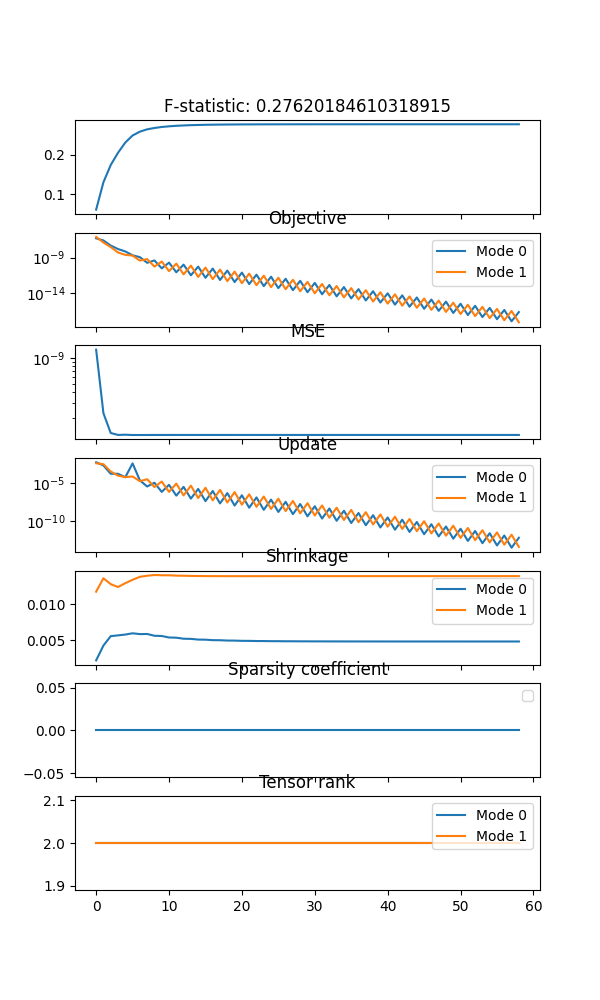

In [8]:
if hoda.keep_train_info:
    fig, axs = plt.subplots(7,1, sharex=True, figsize=(6,10))

    axs[0].set_title(f"F-statistic: {hoda.train_info_['f_stat'][-1]}")
    axs[0].plot(hoda.train_info_["f_stat"])

    axs[1].set_title('Objective')
    axs[1].semilogy(np.asarray(hoda.train_info_["mode_objective"]).T, label=['Mode 0', 'Mode 1'])
    axs[1].legend()

    axs[2].set_title('MSE')
    axs[2].semilogy(hoda.train_info_["mse"])

    axs[3].set_title('Update')
    axs[3].semilogy(cupy.asnumpy(cupy.asarray(hoda.train_info_["mode_update"])).T, label=['Mode 0', 'Mode 1'])
    axs[3].legend()

    axs[4].set_title('Shrinkage')
    axs[4].plot(np.asarray(hoda.train_info_["mode_shrinkage"]).T, label=['Mode 0', 'Mode 1'])
    axs[4].legend()
    
    axs[5].set_title('Sparsity coefficient')
    axs[5].plot(cupy.asnumpy(cupy.asarray([l for l in hoda.train_info_['lambd']])))
    axs[5].legend()

    axs[6].set_title('Tensor rank')
    axs[6].plot(cupy.asnumpy(cupy.asarray(hoda.train_info_["mode_rank"])).T, label=['Mode 0', 'Mode 1'])
    axs[6].legend()

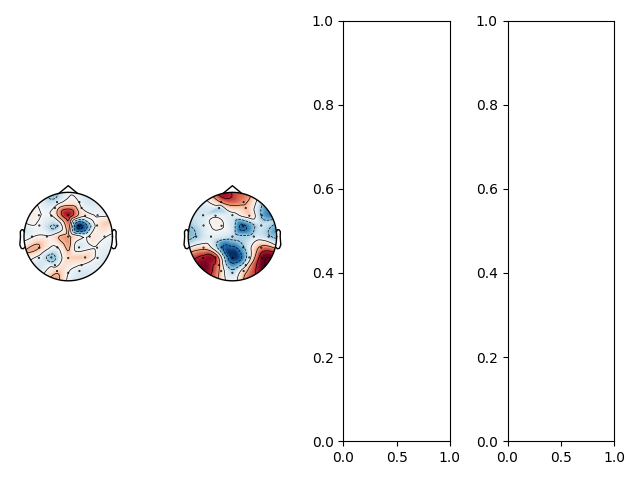

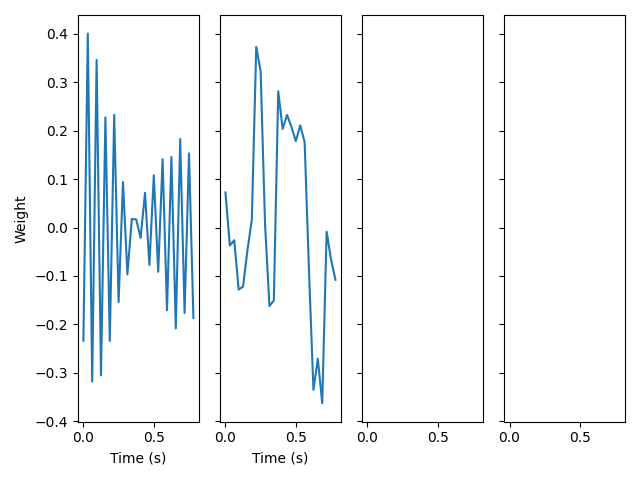

In [9]:
col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
for i in range(hoda.rank_[0]):
    w = cupy.asnumpy(hoda.scalings_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)

n_row = int( np.ceil(hoda.rank_[1] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_[1]):
    w = cupy.asnumpy(hoda.scalings_[1][:,i])
    axs.flatten()[i].plot(epochs.times, w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


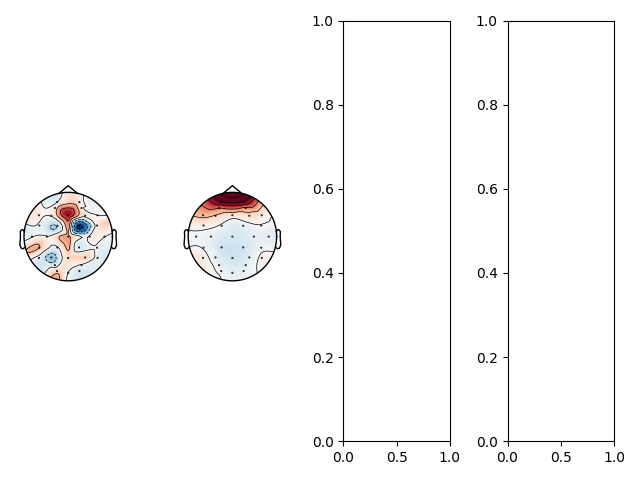

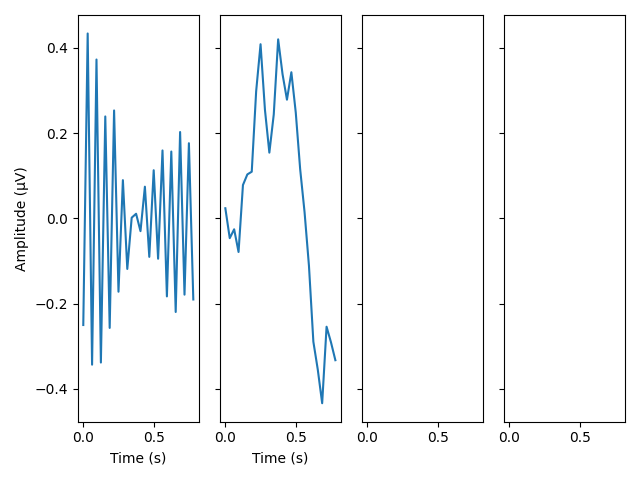

In [10]:
n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
for i in range(hoda.rank_[0]):
    a = cupy.asnumpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)


n_row = int(np.ceil(hoda.rank_[1] / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_[1]):
    a = cupy.asnumpy(A[:,i])
    axs.flatten()[i].plot(epochs.times, a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude (µV)');

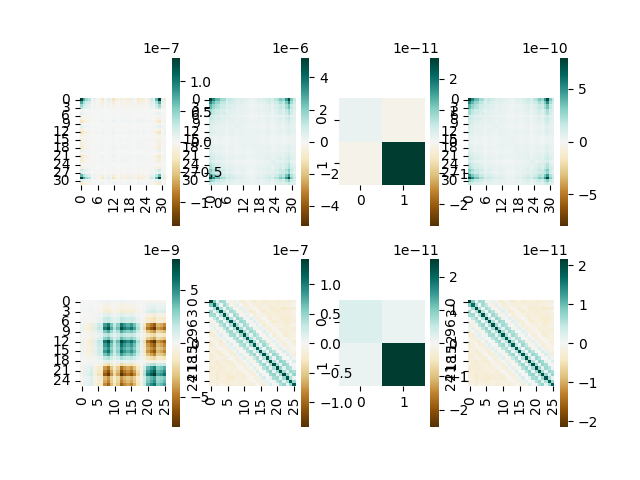

In [11]:
_, axs = plt.subplots(2,4,)
for k in range(2):
    
    scatter_b = cupy.asnumpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(scatter_b))
    axs[k,0].set_aspect('equal')
    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,0])    
    
    scatter_w = cupy.asnumpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(scatter_w))
    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,1])    
    axs[k,1].set_aspect('equal')


    cov_l= cupy.asnumpy(hoda.cov_l_[k])
    vmax = np.max(np.abs(cov_l))
    sns.heatmap(cov_l, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,2])    
    axs[k,2].set_aspect('equal')


    cov_w=  cupy.asnumpy(hoda.cov_w_[k])
    vmax = np.max(np.abs(cov_w))
    sns.heatmap(cov_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,3])    
    axs[k,3].set_aspect('equal')

In [12]:
Xt = hoda.transform(X)

In [13]:
"""
from sklearn.manifold import TSNE
import math

Xt_viz = cupy.asnumpy(Xt.reshape((Xt.shape[0],-1)))
if Xt_viz.shape[-1] > 3:
    tsne  = TSNE(n_components=min(3, math.prod(Xt.shape[1:])), n_jobs=-1)
    Xt_viz = tsne.fit_transform(Xt_viz)
fig = plt.figure()
if Xt_viz.shape[-1] == 2:
    ax = fig.add_subplot()
    ax.scatter(Xt_viz[y=='Target'][:,0], Xt_viz[y=='Target'][:,1])
    ax.scatter(Xt_viz[y=='NonTarget'][:,0], Xt_viz[y=='NonTarget'][:,1])
else:
    ax = fig.add_subplot(projection='3d')
    ax.scatter(Xt_viz[y=='Target'][:,0], Xt_viz[y=='Target'][:,1], Xt_viz[y=='Target'][:,2])
    ax.scatter(Xt_viz[y=='NonTarget'][:,0], Xt_viz[y=='NonTarget'][:,1], Xt_viz[y=='NonTarget'][:,2])
fig.show()
"""

"\nfrom sklearn.manifold import TSNE\nimport math\n\nXt_viz = cupy.asnumpy(Xt.reshape((Xt.shape[0],-1)))\nif Xt_viz.shape[-1] > 3:\n    tsne  = TSNE(n_components=min(3, math.prod(Xt.shape[1:])), n_jobs=-1)\n    Xt_viz = tsne.fit_transform(Xt_viz)\nfig = plt.figure()\nif Xt_viz.shape[-1] == 2:\n    ax = fig.add_subplot()\n    ax.scatter(Xt_viz[y=='Target'][:,0], Xt_viz[y=='Target'][:,1])\n    ax.scatter(Xt_viz[y=='NonTarget'][:,0], Xt_viz[y=='NonTarget'][:,1])\nelse:\n    ax = fig.add_subplot(projection='3d')\n    ax.scatter(Xt_viz[y=='Target'][:,0], Xt_viz[y=='Target'][:,1], Xt_viz[y=='Target'][:,2])\n    ax.scatter(Xt_viz[y=='NonTarget'][:,0], Xt_viz[y=='NonTarget'][:,1], Xt_viz[y=='NonTarget'][:,2])\nfig.show()\n"

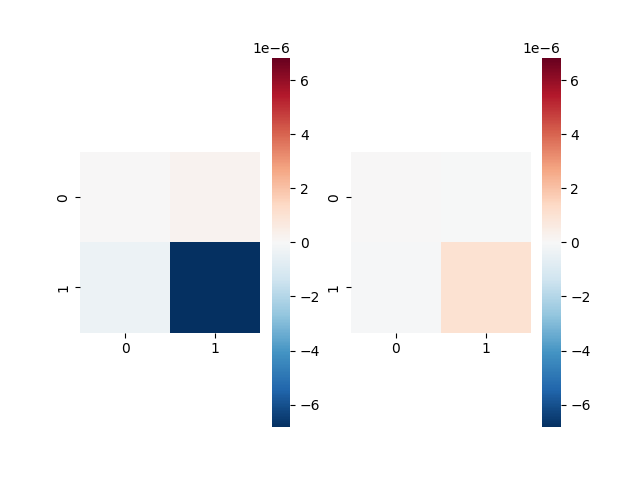

In [14]:
target_avg = cupy.asnumpy(Xt[y=='Target'].mean(axis=0))
nontarget_avg = cupy.asnumpy(Xt[y=='NonTarget'].mean(axis=0))
fig, axs= plt.subplots(1,2)
vmax = max(np.max(np.abs(target_avg)), np.max(np.abs(nontarget_avg)))
sns.heatmap(target_avg, ax=axs[0], center=0, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
sns.heatmap(nontarget_avg, ax=axs[1], center=0, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
for ax in axs:
    ax.set_aspect(1)

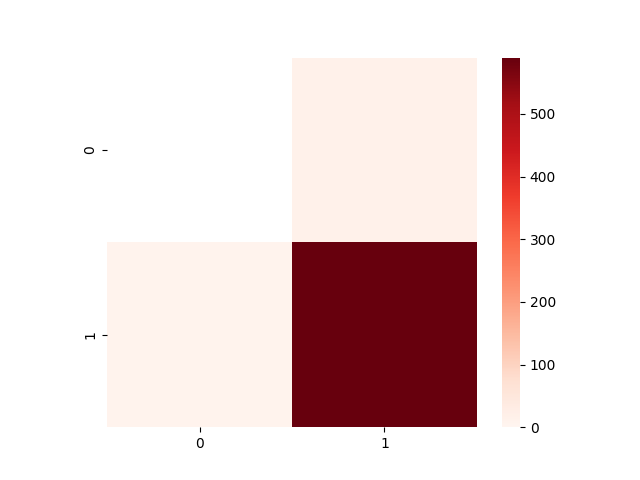

In [15]:
import scipy.stats
import seaborn as sns

samples = []
for c in hoda.classes_:
    samples.append(cupy.asnumpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
p = np.nan_to_num(p, nan=1)
fig, ax = plt.subplots(1,1)
sns.heatmap(F, vmin=0, mask=p>0.05, ax=ax, cmap='Reds')
ax.set_aspect(1)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


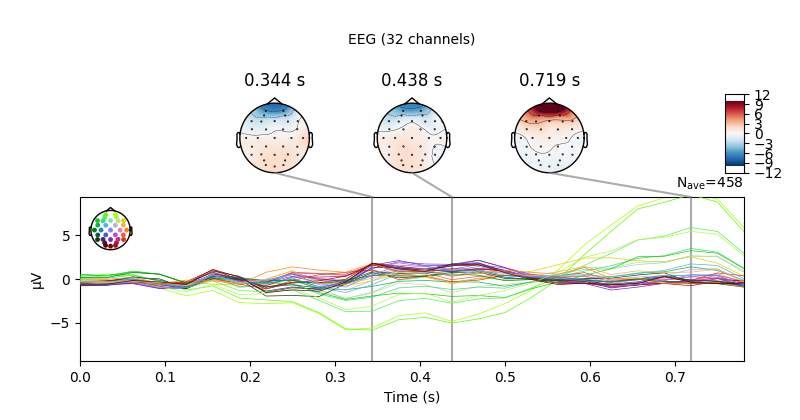

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


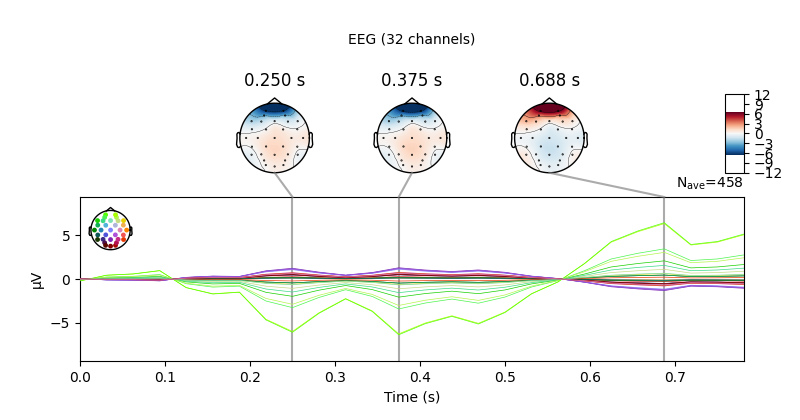

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


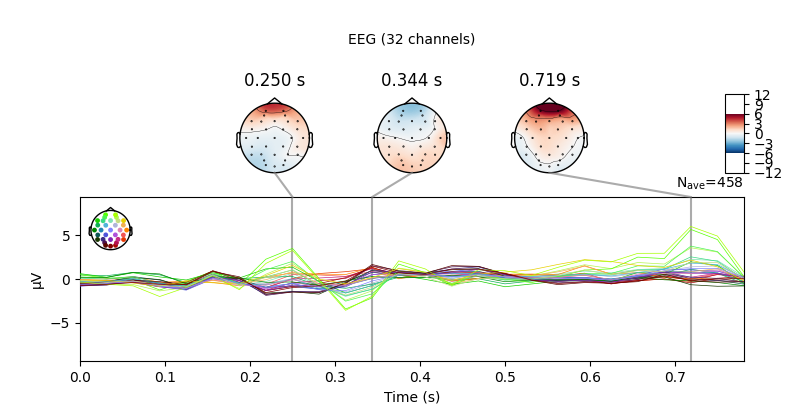

In [16]:
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
vmax = np.max(np.abs(target.data))
vmax = max(vmax, np.max(np.abs(non_target.data)))
vmax *=1.1e6

joint_args=dict(
    ts_args=dict(
        ylim=dict(eeg=[-vmax,vmax]),
        unit=True,
    )
)


contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint(**joint_args)

epochs_rec = epochs.copy()
epochs_rec._data = cupy.asnumpy(hoda.inv_transform(hoda.transform(epochs.get_data())))

target = epochs_rec['Target'].average()
non_target = epochs_rec['NonTarget'].average()
contrast_rec = combine_evoked([target, non_target], weights=[1,-1])
_= contrast_rec.plot_joint(**joint_args)

epochs_defl = epochs.copy()
epochs_defl._data -= epochs_rec.get_data()

target = epochs_defl['Target'].average()
non_target = epochs_defl['NonTarget'].average()
contrast_defl = combine_evoked([target, non_target], weights=[1,-1])
_= contrast_defl.plot_joint(**joint_args)

In [17]:
#contrast_rec.animate_topomap(times = contrast_defl.times, frame_rate=contrast.info['sfreq'], blit=False, butterfly=True)

In [18]:
#contrast_defl.animate_topomap(times = contrast_defl.times, frame_rate=contrast.info['sfreq'], blit=False, butterfly=True)

## Classification

0.779003871992587


/data/.virtualenvs/hoda/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


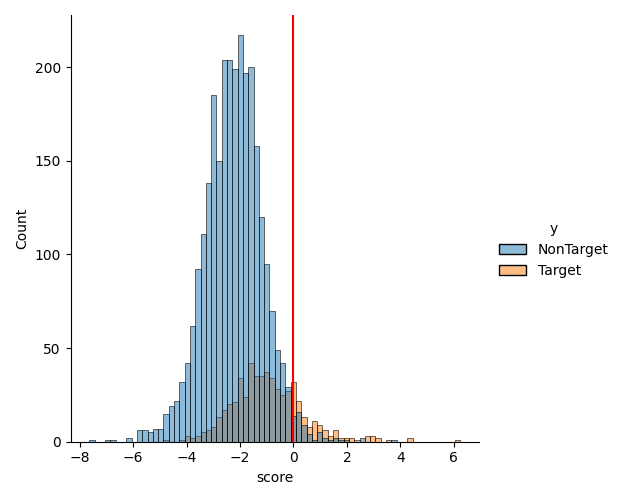

In [19]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
import pandas as pd

Xt = hoda.transform(X)
Xt_flat = cupy.asnumpy(Xt.reshape((Xt.shape[0],-1)))
lda = LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr') 
lda.fit(Xt_flat, y)
score_pred = lda.decision_function(Xt_flat)
df = pd.DataFrame(dict(score=score_pred,y=y))
sns.displot(df, x='score', hue='y')
plt.axvline(0, color='red')
print(roc_auc_score(y,score_pred))